In [2]:
import numpy as np
import matplotlib.pyplot as plt

# RWM, MALA and HMC for the standard Gaussian

Let $\pi$ be the density of $N(0, I_d)$: 
\begin{align*}
    \pi(x) \propto \exp \left(-\|x\|^2 \right)
\end{align*}
We will investigate the performance of RWM (Random Walk Metropolis), MALA (Metropolis Adjusted Langevin Algorithm) and HMC (Hamiltonian Monte Carlo) to draw $N$ Markov Chain samples from $\pi$. 

In [3]:
#log pi(x) upto an additive constant
def logpi(x):
    return -0.5 * np.sum(x**2)

## RWM

Let us first start with RWM which generates proposals as 
\begin{align*}
  y = x + \sigma z 
\end{align*}
where $z \sim N(0, I_d)$. $\sigma$ is the important tuning parameter. Here is the code. Note that the acceptance probability formula is simpler (just $\min(1, \pi(y)/\pi(x))$) because this proposal is symmetric. 

In [4]:
def run_rwm(x0, nsteps, sigma, random_seed=123):
    rng = np.random.default_rng(random_seed)
    d = len(x0)
    x = x0.copy()
    samples = np.empty((nsteps, d))
    accepted = 0

    for t in range(nsteps):
        y = x + sigma * rng.normal(size=d)
        logr = logpi(y) - logpi(x)
        if np.log(rng.uniform()) < logr:
            x = y
            accepted += 1
        samples[t] = x

    return samples, accepted / nsteps

In [14]:
d = 5000
x0 = np.zeros(d)
N = 50000
sigma_rwm = 0.3
samples_rwm, acc_rwm = run_rwm(x0, N, sigma_rwm, random_seed=1)
print(f"RWM acceptance rate: {acc_rwm:.4f}")

RWM acceptance rate: 0.0000


When $\sigma = 0.3$, the above code has no acceptances, so the chain does not move from its initial position. We have to reduce the value of $\sigma$. In lecture 32, we argued that we can get non-trivial acceptance if $\sigma$ is chosen as $c/\sqrt{d}$ for some constant $c$. This suggests the following. 

In [15]:
c = 2
sigma_rwm = c/np.sqrt(d)
samples_rwm, acc_rwm = run_rwm(x0, N, sigma_rwm, random_seed=1)
print(f"RWM acceptance rate: {acc_rwm:.4f}")

RWM acceptance rate: 0.2971


Indeed, we now obtain an acceptance rate that is not abysmally low. To see if the chain has mixed well, let us check out some diagnostics. Let us pick an arbitrary coordinate, say, the first coordinate, and plot the sampled values of the first coordinate with time, as well as the histogram of the values of the first coordinate. 

In [16]:
x1_rwm = samples_rwm[:, 0]


Below is the trace plot of the first coordinate values. 

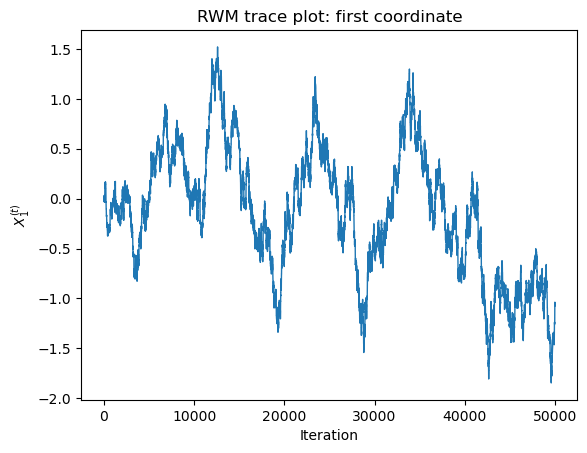

In [17]:
plt.plot(x1_rwm, lw=1)
plt.xlabel("Iteration")
plt.ylabel(r"$X_1^{(t)}$")
plt.title("RWM trace plot: first coordinate")
plt.show()

Below is the histogram of the first coordinate values. 

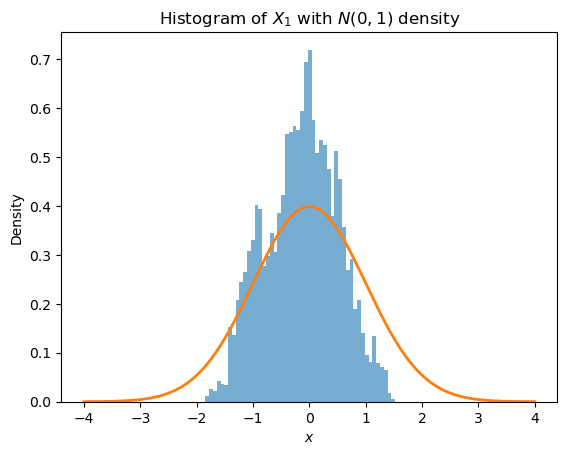

In [18]:
plt.hist(x1_rwm, bins=50, density=True, alpha=0.6)
xx = np.linspace(-4, 4, 500)
phi = np.exp(-xx**2 / 2) / np.sqrt(2 * np.pi)
plt.plot(xx, phi, lw=2)
plt.xlabel(r"$x$")
plt.ylabel("Density")
plt.title(r"Histogram of $X_1$ with $N(0,1)$ density")
plt.show()

It is clear (from the above two plots) that the chain has not mixed well. To get better results, we need to significantly increase the number of samples i.e., the value of $N$. Let us compute the mean and variance of the $X_1$ samples (these need to be close to 0 and 1 respectively). 

In [27]:
print(x1_rwm.mean(), x1_rwm.var())

-0.13705490181404734 0.41473920262827707


Clearly they are significantly off from the target values of 0 and 1. 

Let us now look at the trace plot of $\|X\|^2/d$. 

In [19]:
r2_rwm = np.sum(samples_rwm**2, axis=1) / samples_rwm.shape[1]

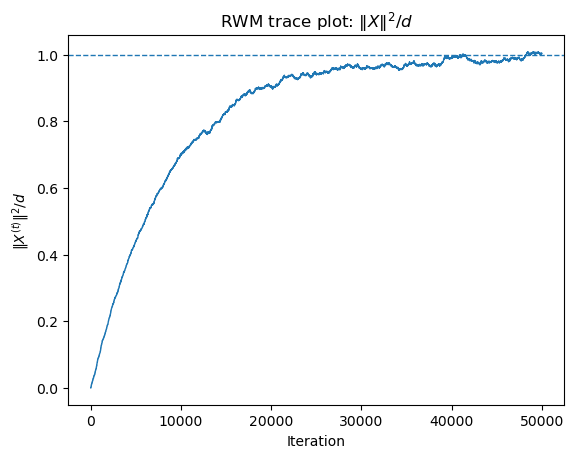

In [20]:
plt.plot(r2_rwm, lw=1)
plt.axhline(1.0, linestyle="--", linewidth=1)
plt.xlabel("Iteration")
plt.ylabel(r"$\|X^{(t)}\|^2 / d$")
plt.title(r"RWM trace plot: $\|X\|^2/d$")
plt.show()

When $X \sim N(0, I_d)$, it is easy to see that $\|X\|^2/d$ has mean 1 and variance $2/d$, which means that it is concentrated at 1. But because we are initializing at 0, the RWM is taking a long time to get up to 1. We can try by changing the initialization to be constant equal to $1$. 

In [24]:
x0 = np.ones(d)
samples_rwm, acc_rwm = run_rwm(x0, N, sigma_rwm, random_seed=1)


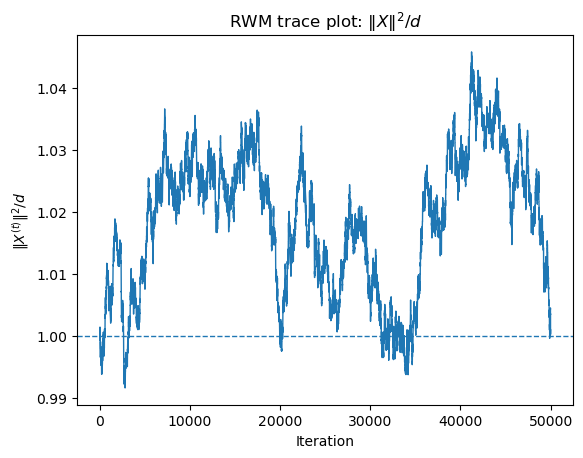

In [25]:
r2_rwm = np.sum(samples_rwm**2, axis=1) / samples_rwm.shape[1]
plt.plot(r2_rwm, lw=1)
plt.axhline(1.0, linestyle="--", linewidth=1)
plt.xlabel("Iteration")
plt.ylabel(r"$\|X^{(t)}\|^2 / d$")
plt.title(r"RWM trace plot: $\|X\|^2/d$")
plt.show()

The chain still does not seem to mix well. Below we compute the mean and variance of the samples of $\|X\|^2/d$. They have to be close to 1 and $2/d$ respectively. 

In [29]:
print(r2_rwm.mean(), r2_rwm.var())
print(1, 2/d)

1.0185066018120852 0.00012376397689145582
1 0.0004


The mean of the samples of $\|X\|^2/d$ is reasonably close to 1, but the variance of the samples is quite far from $2/d$. 

Three other diagnostic tools are AutoCorrelation Function, Effective Sample Size and Running Mean. The AutoCorrelation Function (ACF) is calculated and plotted as follows, for the chain corresponding to the first coordinate. 

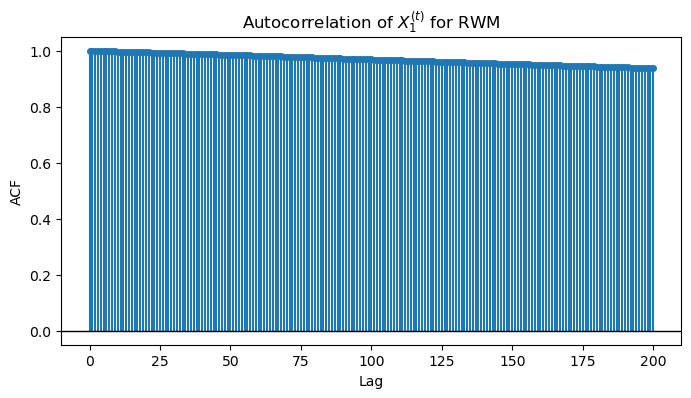

In [33]:
def autocorr(x, max_lag):
    x = np.asarray(x, dtype=float)
    x = x - x.mean()
    n = len(x)
    var = np.dot(x, x) / n

    acf = np.empty(max_lag + 1)
    acf[0] = 1.0
    for k in range(1, max_lag + 1):
        acf[k] = np.dot(x[:-k], x[k:]) / ((n - k) * var)
    return acf

max_lag = 200
acf_x1_rwm = autocorr(x1_rwm, max_lag)

lags = np.arange(max_lag + 1)
plt.figure(figsize=(8, 4))
plt.vlines(lags, 0, acf_x1_rwm)
plt.plot(lags, acf_x1_rwm, "o", markersize=4)
plt.axhline(0, color="black", linewidth=1)
plt.xlabel("Lag")
plt.ylabel("ACF")
plt.title(r"Autocorrelation of $X_1^{(t)}$ for RWM")
plt.show()

The autocorrelation values are very close to 1 even for lags as large as 200 which is indicative of very poor mixing. 

Next we shall calculate the ESS (Effective Sample Size). It is defined as
\begin{align*}
   ESS = \frac{n}{1 + 2 \sum_{k=1}^K \rho_k}
\end{align*}
where $\rho_k$ is the AutoCorrelation at lag $k$. Also $K$ is the lag at which the autocorrelation $\rho_k$ first becomes non-positive. Larger values of ESS indicate good mixing. A very small value of ESS indicates poor mixing. The ESS value for the chain corresponding to the first coordinate is calculated as follows. 

In [34]:
def ess(x, max_lag=1000):
    """
    Simple ESS estimator using initial positive sequence truncation.
    """
    acf = autocorr(x, max_lag=max_lag)
    s = 0.0
    for k in range(1, len(acf)):
        if acf[k] <= 0:
            break
        s += acf[k]
    n = len(x)
    return n / (1 + 2 * s)
print(f"ESS for RWM: {ess(x1_rwm):.2f}")

ESS for RWM: 29.66


This value of ESS is very small, again indicative of poor mixing. 

Finally, we compute the running mean of the samples of $X_1^{(t)}$. These are the means of the first $n$ samples of $X_1$. In other words, the running mean tells us what estimate of the target mean we would report if we stopped the chain there. As $n$ grows, a well-mixed chain should make the running mean settle down near the true value. 

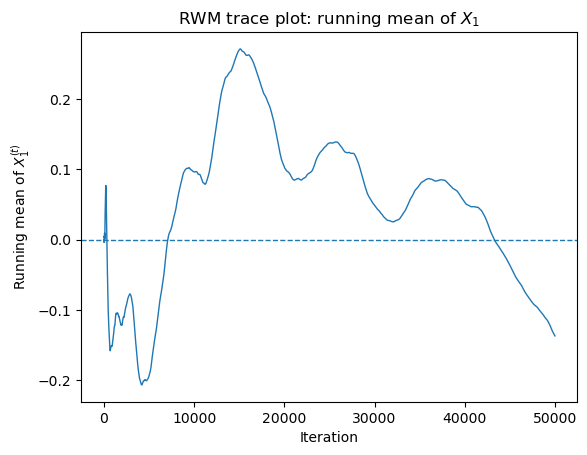

In [35]:
def running_mean(x):
    x = np.asarray(x, dtype=float)
    return np.cumsum(x) / np.arange(1, len(x) + 1)
plt.plot(running_mean(x1_rwm), lw=1)
plt.axhline(0, linestyle="--", linewidth=1)
plt.xlabel("Iteration")
plt.ylabel(r"Running mean of $X_1^{(t)}$")
plt.title(r"RWM trace plot: running mean of $X_1$")
plt.show()

This running mean is clearly all over the place, again indicative of poor mixing. 

## MALA

We shall now repeat the analysis for MALA. In MALA the proposal is given by: 
\begin{align*}
   y = x + \frac{\sigma^2}{2} \nabla \log \pi(x) + \sigma z
\end{align*}
where again $z \sim N(0, I_d)$. Because $\pi(x) \propto \exp(-\|x\|^2/2)$, we have $\nabla \log \pi(x) = -x$ so that the MALA proposal is
\begin{align*}
   y = (1 - \sigma^2/2) x + \sigma z. 
\end{align*}

In [38]:
def mala_mean(x, sigma):
    # proposal mean for target N(0, I_d)
    return (1 - 0.5 * sigma**2) * x


def log_q_mala(y, x, sigma):
    # log density of q(y | x) up to additive constant
    m = mala_mean(x, sigma)
    diff = y - m
    return -0.5 * np.dot(diff, diff) / (sigma**2)


def run_mala(x0, nsteps, sigma, random_seed = 123):
    rng = np.random.default_rng(random_seed)
    d = len(x0)
    x = x0.copy()
    samples = np.empty((nsteps, d))
    accepted = 0

    for t in range(nsteps):
        mean_x = mala_mean(x, sigma)
        y = mean_x + sigma * rng.normal(size=d)

        logr = (
            logpi(y) - logpi(x)
            + log_q_mala(x, y, sigma)
            - log_q_mala(y, x, sigma)
        )

        if np.log(rng.uniform()) < logr:
            x = y
            accepted += 1
        samples[t] = x

    return samples, accepted / nsteps

In [39]:
d = 5000
x0 = np.zeros(d)
N = 50000
sigma_mala = 0.3
samples_mala, acc_mala = run_mala(x0, N, sigma_mala, random_seed=1)
print(f"MALA acceptance rate: {acc_mala:.4f}")

MALA acceptance rate: 0.8036


For $\sigma = 0.3$ which resulted in 0 acceptances for RWM, gives a nontrivial acceptance rate for MALA. The theoretical analysis for Lecture 32 recommended a scaling for $\sigma$ of the form $c/d^{1/6}$.

In [43]:
c = 1 #with c = 2, we are getting 0 acceptances. 
sigma_mala = c/(d ** (1/6))
samples_mala, acc_mala = run_mala(x0, N, sigma_mala, random_seed=1)
print(f"MALA acceptance rate: {acc_mala:.4f}")

MALA acceptance rate: 0.8982


Let us now check the mixing for the first coordinate. 

In [47]:
sigma_mala = 0.3
samples_mala, acc_mala = run_mala(x0, N, sigma_mala, random_seed=1)
print(f"MALA acceptance rate: {acc_mala:.4f}")
x1_mala = samples_mala[:, 0]


MALA acceptance rate: 0.8036


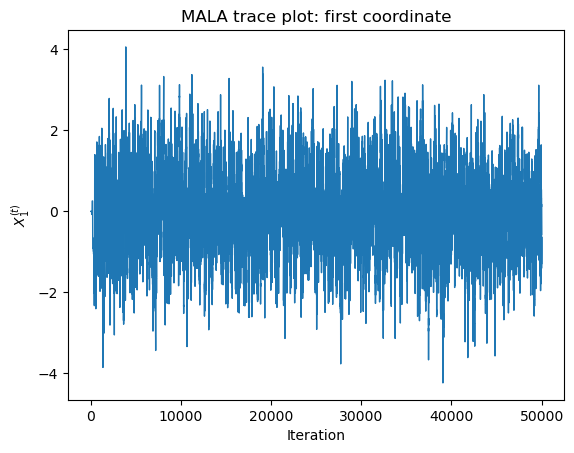

In [48]:
plt.plot(x1_mala, lw=1)
plt.xlabel("Iteration")
plt.ylabel(r"$X_1^{(t)}$")
plt.title("MALA trace plot: first coordinate")
plt.show()

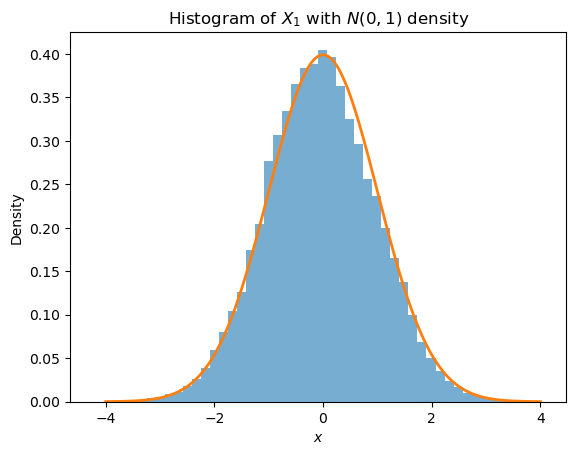

In [49]:
plt.hist(x1_mala, bins=50, density=True, alpha=0.6)
xx = np.linspace(-4, 4, 500)
phi = np.exp(-xx**2 / 2) / np.sqrt(2 * np.pi)
plt.plot(xx, phi, lw=2)
plt.xlabel(r"$x$")
plt.ylabel("Density")
plt.title(r"Histogram of $X_1$ with $N(0,1)$ density")
plt.show()

In [52]:
print(x1_mala.mean(), x1_mala.var())
#target is 0 and 1

-0.042182961541383256 0.9982065613059291


In [53]:
r2_mala = np.sum(samples_mala**2, axis=1) / samples_mala.shape[1]

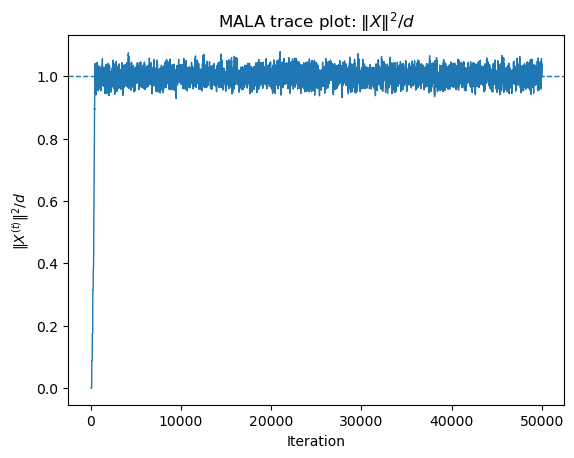

In [55]:
plt.plot(r2_mala, lw=1)
plt.axhline(1.0, linestyle="--", linewidth=1)
plt.xlabel("Iteration")
plt.ylabel(r"$\|X^{(t)}\|^2 / d$")
plt.title(r"MALA trace plot: $\|X\|^2/d$")
plt.show()

This value $\|X\|^2/d$ gets up to 1 quickly and then oscillates around it. 

In [56]:
print(r2_mala.mean(), r2_mala.var())
print(1, 2/d)

0.9937959156040489 0.005089930914902908
1 0.0004


The mean is near 1 but the variance is somewhat inflated. 

Let us now plot the autocorrelations and running means, and also calculate ESS for the MALA samples (corresponding to the first coordinate). 

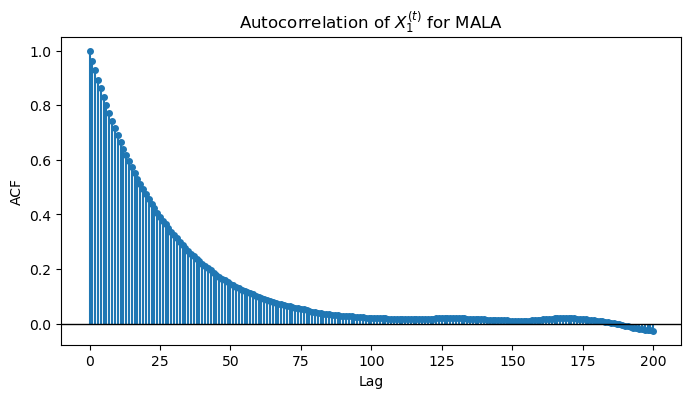

In [57]:
max_lag = 200
acf_x1_mala = autocorr(x1_mala, max_lag)

lags = np.arange(max_lag + 1)
plt.figure(figsize=(8, 4))
plt.vlines(lags, 0, acf_x1_mala)
plt.plot(lags, acf_x1_mala, "o", markersize=4)
plt.axhline(0, color="black", linewidth=1)
plt.xlabel("Lag")
plt.ylabel("ACF")
plt.title(r"Autocorrelation of $X_1^{(t)}$ for MALA")
plt.show()

In [58]:
print(f"ESS for MALA: {ess(x1_mala):.2f}")

ESS for MALA: 924.56


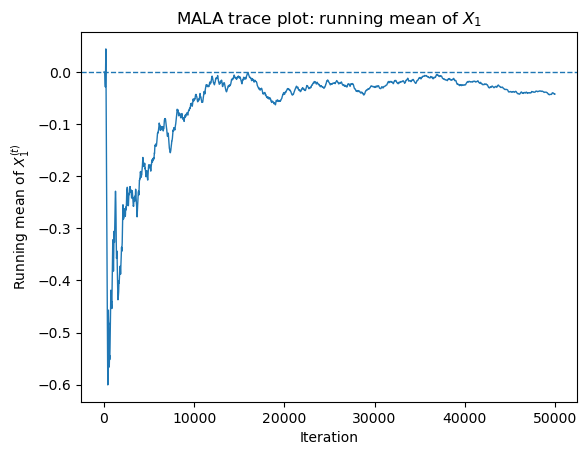

In [60]:
plt.plot(running_mean(x1_mala), lw=1)
plt.axhline(0, linestyle="--", linewidth=1)
plt.xlabel("Iteration")
plt.ylabel(r"Running mean of $X_1^{(t)}$")
plt.title(r"MALA trace plot: running mean of $X_1$")
plt.show()

The ESS is much higher compared to RWM. The running means also nearly stabilize near the value 0 (although they are still slightly less than the target value 1). 

Overall these diagnostics show that MALA is performing much better in this example compared to RWM. The diagnostics will further improve if we increase the number of samples. 

## HMC

Next let us look at the HMC algorith. The proposal here is generated by solving the ODE: 
\begin{align*} 
   x(0) = x ~~~ \dot{x}(0) = z ~~~ \ddot{x}(t) = \nabla \log \pi(x(t)) ~~~ y = x(\sigma)
\end{align*}
where again $z \sim N(0, I_d)$. Because $\nabla \log \pi(x) = -x$, we get
\begin{align*} 
   x(0) = x ~~~ \dot{x}(0) = z ~~~ \ddot{x}(t) = - x(t) ~~~ y = x(\sigma)
\end{align*}
whose solution is given by: 
\begin{align*}
   y = x \cos \sigma + z \sin \sigma. 
\end{align*}
Here also $\sigma$ needs to be chosen. However, the great thing about this chain is that it satisfies detailed balance with respect to $\pi = N(0, I_d)$ for every value of $\sigma$. This allows us to choose $\sigma$ large.


In [63]:
def run_hmc_exact(x0, nsteps, sig, random_seed=123):
    rng = np.random.default_rng(random_seed)
    d = len(x0)
    x = x0.copy()
    samples = np.empty((nsteps, d))

    c = np.cos(sig)
    s = np.sin(sig)

    for t in range(nsteps):
        z = rng.normal(size=d)
        x = c * x + s * z
        samples[t] = x

    return samples, 1.0

In [64]:
sigma_hmc = 0.5 #a large value (for this value, both MALA and RWM are getting 0 acceptances)
N = 50000
x0 = np.zeros(d)
samples_hmc, acc_hmc = run_hmc_exact(x0, N, sigma_hmc, random_seed=3)
print(f"HMC acceptance rate: {acc_hmc:.4f}")

HMC acceptance rate: 1.0000


The acceptance rate equals 1 because the algorithm returns 1 by default as the acceptance probability equals 1. 

We now check mixing for the first coordinate. 

In [65]:
x1_hmc = samples_hmc[:, 0]


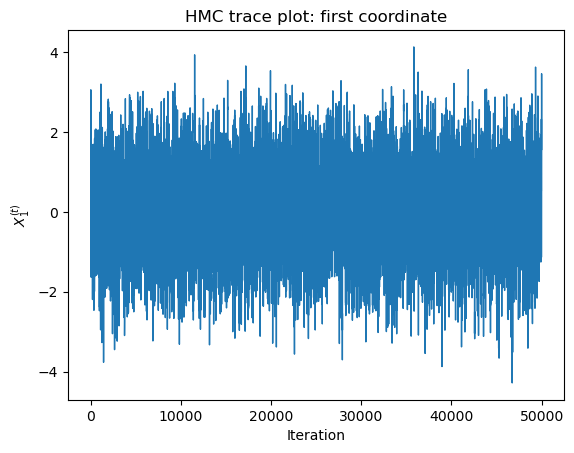

In [66]:
plt.plot(x1_hmc, lw=1)
plt.xlabel("Iteration")
plt.ylabel(r"$X_1^{(t)}$")
plt.title("HMC trace plot: first coordinate")
plt.show()

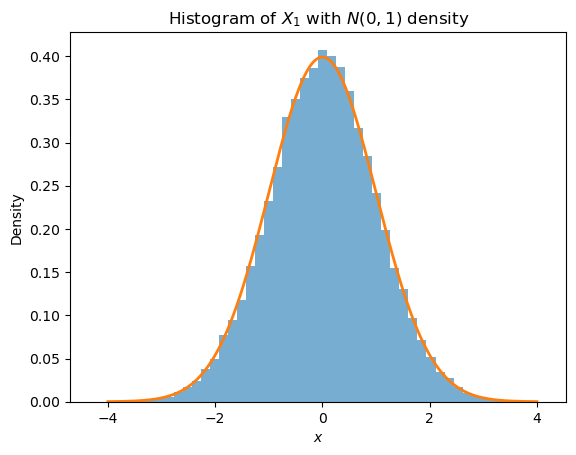

In [67]:
plt.hist(x1_hmc, bins=50, density=True, alpha=0.6)
xx = np.linspace(-4, 4, 500)
phi = np.exp(-xx**2 / 2) / np.sqrt(2 * np.pi)
plt.plot(xx, phi, lw=2)
plt.xlabel(r"$x$")
plt.ylabel("Density")
plt.title(r"Histogram of $X_1$ with $N(0,1)$ density")
plt.show()

In [69]:
print(x1_hmc.mean(), x1_hmc.var())
#target is 0 and 1

0.012082827787888887 0.9871280350280265


In [70]:
r2_hmc = np.sum(samples_hmc**2, axis=1) / samples_hmc.shape[1]

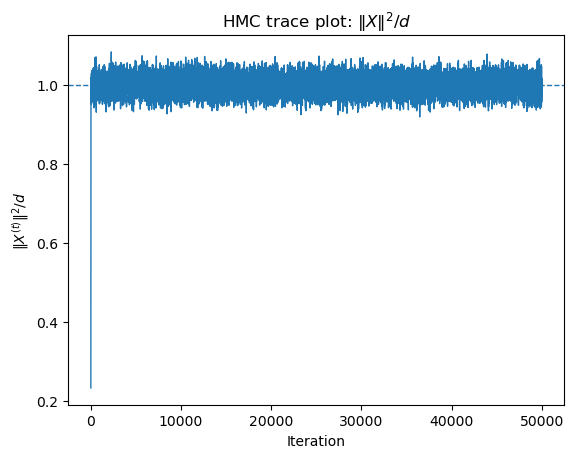

In [71]:
plt.plot(r2_hmc, lw=1)
plt.axhline(1.0, linestyle="--", linewidth=1)
plt.xlabel("Iteration")
plt.ylabel(r"$\|X^{(t)}\|^2 / d$")
plt.title(r"HMC trace plot: $\|X\|^2/d$")
plt.show()

In [72]:
print(r2_hmc.mean(), r2_hmc.var())
print(1, 2/d)

0.9999760675851913 0.0004355878715516191
1 0.0004


This mean and variance match those of the target much more closely (compared even to MALA). 

Here is the autocorrelation plot of HMC. 

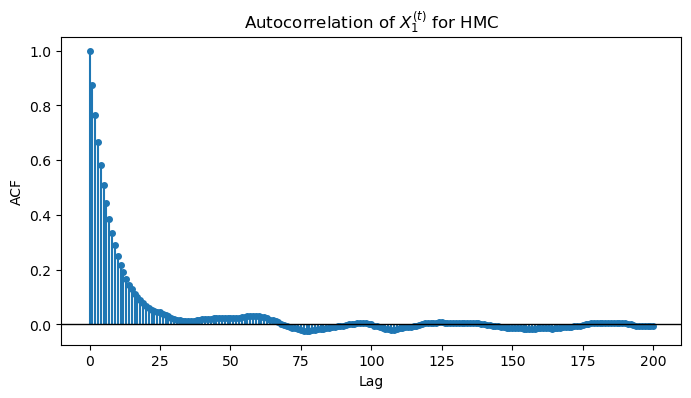

In [73]:
max_lag = 200
acf_x1_hmc = autocorr(x1_hmc, max_lag)

lags = np.arange(max_lag + 1)
plt.figure(figsize=(8, 4))
plt.vlines(lags, 0, acf_x1_hmc)
plt.plot(lags, acf_x1_hmc, "o", markersize=4)
plt.axhline(0, color="black", linewidth=1)
plt.xlabel("Lag")
plt.ylabel("ACF")
plt.title(r"Autocorrelation of $X_1^{(t)}$ for HMC")
plt.show()

Next is the ESS for HMC. 

In [77]:
print(f"ESS for HMC: {ess(x1_hmc):.2f}")
print(f"ESS ratio (HMC/MALA): {ess(x1_hmc)/ess(x1_mala):.2f}")

ESS for HMC: 3095.52
ESS ratio (HMC/MALA): 3.35


Finally, we plot below the running means for HMC (first coordinate). 

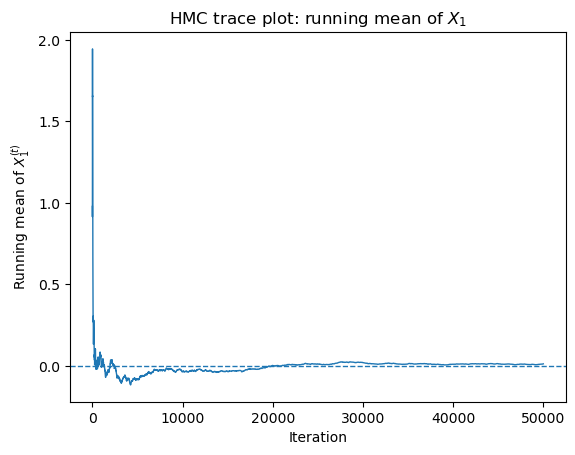

In [76]:
plt.plot(running_mean(x1_hmc), lw=1)
plt.axhline(0, linestyle="--", linewidth=1)
plt.xlabel("Iteration")
plt.ylabel(r"Running mean of $X_1^{(t)}$")
plt.title(r"HMC trace plot: running mean of $X_1$")
plt.show()

Overall, the conclusion is that both MALA and HMC work very well for this problem, even though the dimension is very high ($d = 5000$). The best method is clearly HMC because the ESS (for the first coordinate samples) for HMC is more than 3 times bigger than that of MALA. The RWM method struggles with the high-dimensionality. 

You can go back to the HMC code and increase $\sigma$ even more (e.g., $\sigma = 1$) to see if you get better results. 